In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sample_population(N, m, device):
    # equal priors, y in {-1, +1}
    y = torch.where(
        torch.rand(N, device=device) < 0.5,
        torch.tensor(-1.0, device=device),
        torch.tensor(1.0, device=device),
    )
    x = y * m + torch.randn(N, device=device)  # variance 1
    return x, y


def init_params(n_hidden=100, scale=0.2, device=None):
    v = torch.randn(n_hidden, device=device) * scale
    w = torch.randn(n_hidden, device=device) * scale
    b = torch.randn(n_hidden, device=device) * scale
    c = torch.tensor(0.0, device=device)
    return (v, w, b, c)


def forward(x, params):
    # params: (v, w, b, c), hidden width = len(v)
    v, w, b, c = params
    s = x[:, None] * w[None, :] + b[None, :]
    h = torch.relu(s)
    f = h @ v + c
    cache = (s, h)
    return f, cache


def gradients(x, y, mu, params):
    """
    Population-gradient estimator for gradient ascent on:
        L = const - 0.5 * E[(f - y*mu)^2]
    Using r = y*mu - f.

    Returns:
        dmu (scalar tensor), dparams=(dv, dw, db, dc)
    """    
    v, w, b, c = params
    f, (s, h) = forward(x, params)
    r = y * mu - f

    # dL/dmu = E[y f] - mu
    dmu = torch.mean(y * f) - mu

    ind = (s > 0.0).to(x.dtype)

    dv = torch.mean(r[:, None] * h, dim=0)
    dw = torch.mean(r[:, None] * (v[None, :] * ind) * x[:, None], dim=0)
    db = torch.mean(r[:, None] * (v[None, :] * ind), dim=0)
    dc = torch.mean(r)

    return dmu, (dv, dw, db, dc)



In [2]:
def run(
    m=2.0,
    n_hidden=100,
    N=200_000,
    steps=10_000,
    lr_mu=0.02,
    lr_theta=0.02,
    track_every=100,
):
    device = get_device()
    print(f"Using device: {device}")

    # Big Monte Carlo sample ~ population expectation
    x, y = sample_population(N=N, m=m, device=device)

    # Initialize parameters
    params = init_params(n_hidden=n_hidden, scale=0.2, device=device)
    mu = torch.tensor(1.0, device=device)  # start nonzero

    mu_hist = np.empty(steps, dtype=float)
    L_hist = np.empty(steps, dtype=float)
    Eyf_hist = np.empty(steps, dtype=float)

    # For compact tracking with many neurons, store parameter norms
    v_norm_hist = np.empty(steps, dtype=float)
    w_norm_hist = np.empty(steps, dtype=float)
    b_norm_hist = np.empty(steps, dtype=float)
    c_hist = np.empty(steps, dtype=float)

    # Distribution tracking for f_w(X): save snapshots every `track_every` steps
    fw_snapshots = []
    fw_snapshot_steps = []

    for t in range(steps):
        dmu, (dv, dw, db, dc) = gradients(x, y, mu, params)

        # Euler step for joint gradient ascent on mu and theta
        mu = mu + lr_mu * dmu

        v, w, b, c = params
        v = v + lr_theta * dv
        w = w + lr_theta * dw
        b = b + lr_theta * db
        c = c + lr_theta * dc
        params = (v, w, b, c)

        # Track
        f, _ = forward(x, params)
        Eyf = torch.mean(y * f)
        L = -0.5 * torch.mean((f - y * mu) ** 2)

        mu_hist[t] = mu.item()
        L_hist[t] = L.item()
        Eyf_hist[t] = Eyf.item()

        v_norm_hist[t] = torch.linalg.norm(v).item()
        w_norm_hist[t] = torch.linalg.norm(w).item()
        b_norm_hist[t] = torch.linalg.norm(b).item()
        c_hist[t] = c.item()

        if (t + 1) % track_every == 0:
            fw_snapshots.append(f.detach().cpu().numpy().copy())
            fw_snapshot_steps.append(t + 1)

        if (t + 1) % max(1, steps // 10) == 0:
            print(f"step {t+1:6d}/{steps} | mu={mu.item():+.6f} | E[Yf]={Eyf.item():+.6f} | L={L.item():+.6f}")

    return (
        mu,
        params,
        mu_hist,
        L_hist,
        Eyf_hist,
        v_norm_hist,
        w_norm_hist,
        b_norm_hist,
        c_hist,
        fw_snapshots,
        fw_snapshot_steps,
        device,
    )




Running with m=2.0, n_hidden=100
Using device: cuda
step   1000/10000 | mu=+0.220964 | E[Yf]=+0.212619 | L=-0.001878
step   2000/10000 | mu=+0.107224 | E[Yf]=+0.103501 | L=-0.000495
step   3000/10000 | mu=+0.054587 | E[Yf]=+0.052791 | L=-0.000159
step   4000/10000 | mu=+0.028700 | E[Yf]=+0.027800 | L=-0.000062
step   5000/10000 | mu=+0.015575 | E[Yf]=+0.015112 | L=-0.000029
step   6000/10000 | mu=+0.008741 | E[Yf]=+0.008496 | L=-0.000016
step   7000/10000 | mu=+0.005082 | E[Yf]=+0.004949 | L=-0.000010
step   8000/10000 | mu=+0.003066 | E[Yf]=+0.002992 | L=-0.000006
step   9000/10000 | mu=+0.001920 | E[Yf]=+0.001877 | L=-0.000005
step  10000/10000 | mu=+0.001250 | E[Yf]=+0.001224 | L=-0.000003
Final mu (m=2.0): +0.00124965
Final E[Yf] (m=2.0): +0.00122410


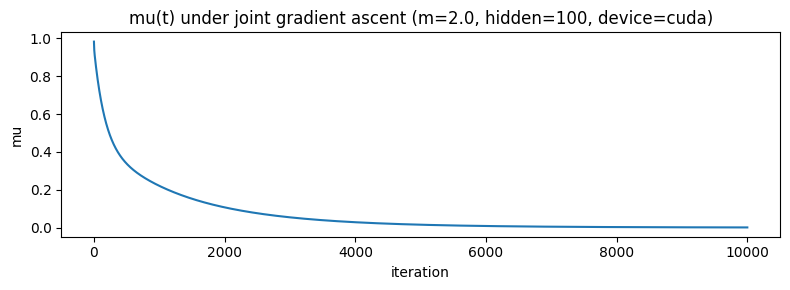

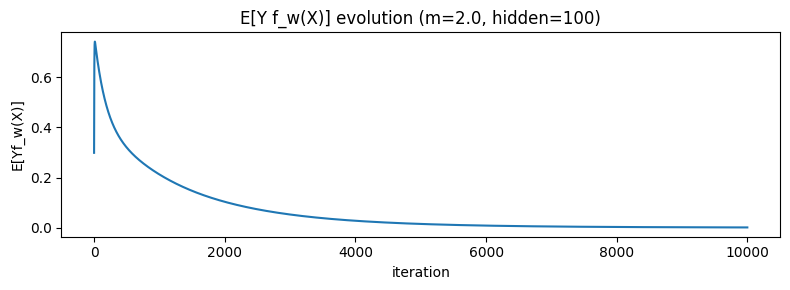

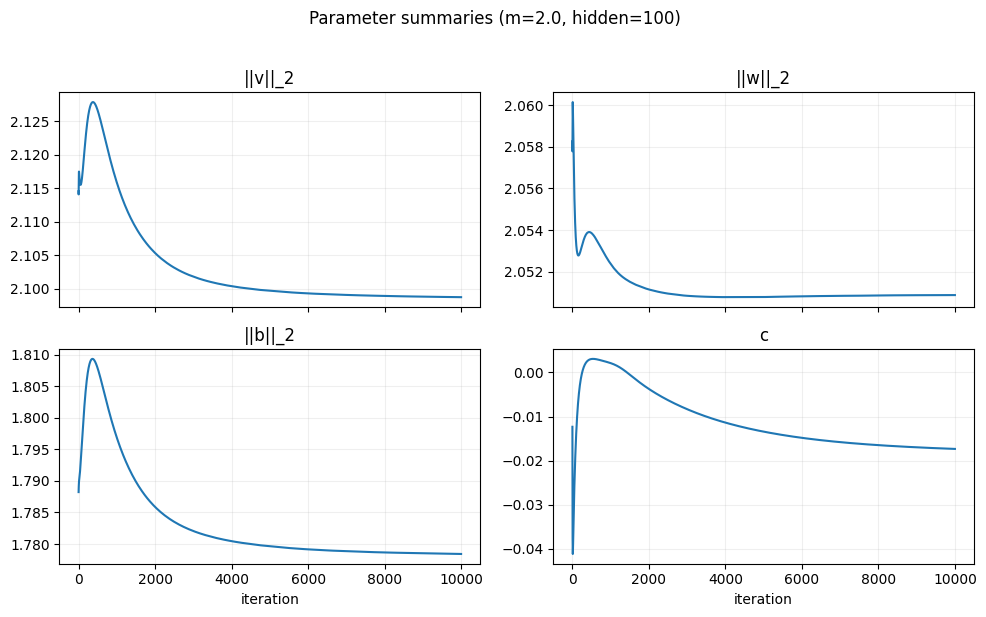

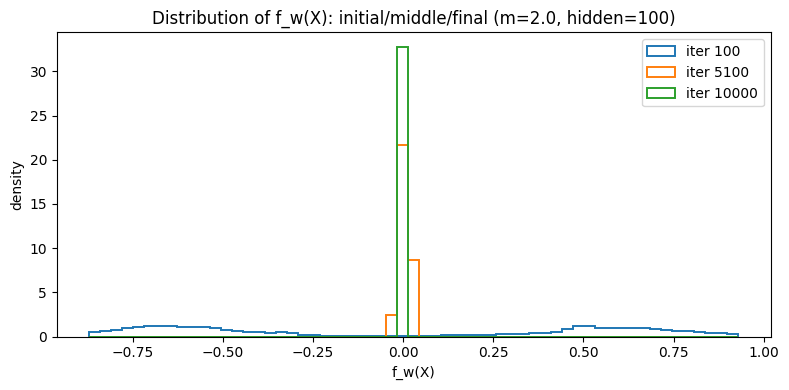

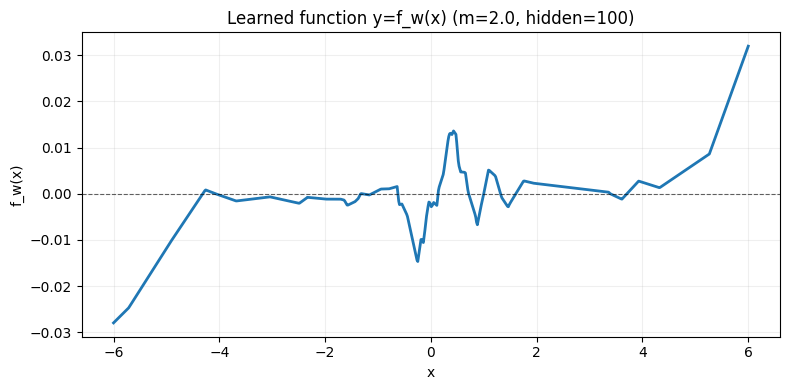

In [3]:
# Run m=2.0 with 100 hidden neurons (PyTorch + GPU if available)
m = 2.0
n_hidden = 100

print("\n" + "=" * 60)
print(f"Running with m={m}, n_hidden={n_hidden}")
(
    mu_final,
    params_final,
    mu_hist,
    L_hist,
    Eyf_hist,
    v_norm_hist,
    w_norm_hist,
    b_norm_hist,
    c_hist,
    fw_snapshots,
    fw_snapshot_steps,
    device,
) = run(
    m=m,
    n_hidden=n_hidden,
    N=200_000,
    steps=10_000,
    lr_mu=0.02,
    lr_theta=0.02,
    track_every=100,
)

print(f"Final mu (m={m}): {mu_final.item():+.8f}")
print(f"Final E[Yf] (m={m}): {Eyf_hist[-1]:+.8f}")

# Plot mu(t)
plt.figure(figsize=(8, 3))
plt.plot(mu_hist)
plt.xlabel("iteration")
plt.ylabel("mu")
plt.title(f"mu(t) under joint gradient ascent (m={m}, hidden={n_hidden}, device={device})")
plt.tight_layout()

# Plot E[Y f_w(X)]
plt.figure(figsize=(8, 3))
plt.plot(Eyf_hist)
plt.xlabel("iteration")
plt.ylabel("E[Yf_w(X)]")
plt.title(f"E[Y f_w(X)] evolution (m={m}, hidden={n_hidden})")
plt.tight_layout()

# Plot parameter summaries
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axes = axes.ravel()
axes[0].plot(v_norm_hist)
axes[0].set_title("||v||_2")
axes[0].grid(alpha=0.2)

axes[1].plot(w_norm_hist)
axes[1].set_title("||w||_2")
axes[1].grid(alpha=0.2)

axes[2].plot(b_norm_hist)
axes[2].set_title("||b||_2")
axes[2].set_xlabel("iteration")
axes[2].grid(alpha=0.2)

axes[3].plot(c_hist)
axes[3].set_title("c")
axes[3].set_xlabel("iteration")
axes[3].grid(alpha=0.2)

plt.suptitle(f"Parameter summaries (m={m}, hidden={n_hidden})", y=1.02)
plt.tight_layout()

# Plot tracked distributions of f_w(X): initial, middle, final snapshot
if fw_snapshots:
    if len(fw_snapshots) == 1:
        show_idx = np.array([0], dtype=int)
    elif len(fw_snapshots) == 2:
        show_idx = np.array([0, 1], dtype=int)
    else:
        show_idx = np.array([0, len(fw_snapshots) // 2, len(fw_snapshots) - 1], dtype=int)

    selected = [fw_snapshots[i] for i in show_idx]
    all_vals = np.concatenate(selected)
    bins = np.linspace(np.percentile(all_vals, 1), np.percentile(all_vals, 99), 60)

    plt.figure(figsize=(8, 4))
    for i in show_idx:
        plt.hist(
            fw_snapshots[i],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.4,
            label=f"iter {fw_snapshot_steps[i]}",
        )
    plt.xlabel("f_w(X)")
    plt.ylabel("density")
    plt.title(f"Distribution of f_w(X): initial/middle/final (m={m}, hidden={n_hidden})")
    plt.legend()
    plt.tight_layout()

# Plot learned function y = f_w(x)
x_grid = torch.linspace(-6, 6, 800, device=device)
y_grid, _ = forward(x_grid, params_final)

plt.figure(figsize=(8, 4))
plt.plot(x_grid.detach().cpu().numpy(), y_grid.detach().cpu().numpy(), linewidth=2.0)
plt.axhline(0.0, color="k", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("x")
plt.ylabel("f_w(x)")
plt.title(f"Learned function y=f_w(x) (m={m}, hidden={n_hidden})")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

